# 03 — Robustness of the niche, and who SPP1-TAM macrophages sit next to (graded)

**Rewritten for the graded `SPP1_TAM_sig`.** The binary "Spp1+ mac" call is dead (spillover;
01/01b/01c). Two questions script 02 sets up but does not close:

### Part A — does the niche association survive a *different* operationalization?
Script 02 already breaks circularity (its niche is a **local mean over non-myeloid cells**).
Part A asks the same biology a second, independent way: run **Gi\*** on non-myeloid cells to
find discrete hypoxia / oxidized-lipid / adenosine / lactate **hotspot zones**, then test
whether macrophages *inside* those zones carry a higher `SPP1_TAM_sig` than macs outside
(Cliff's delta, per tissue). The summary prints 02's ρ next to 03's delta:
**agree → the niche finding is robust to how the niche is defined; disagree → it is fragile.**

### Part B — *"what cell types do they tend to be close to?"*
Neighborhood composition around **high-signature** macrophages, with **low-signature**
macrophages as the control (within-tissue top vs bottom `SPP1_TAM_sig` tertile). Using
low-signature macs as the reference cancels everything shared by macrophage biology — tissue
density, where myeloid cells infiltrate, annotation rate. What survives is specific to the
SPP1-TAM state. The PDF predicts fibroblasts (FAP+ immune-excluding niche) and dying tumor
up, and CD8 *excluded*.

`Erythrocyte` is a flagged non-RBC junk compartment (10% of cells, no haemoglobin; 01c §6b) —
excluded from niche definition, kept visible in the Part B panel as a QC readout.

In [3]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm

import scanpy as sc
import spatialdata as spd

from scipy.stats import norm, mannwhitneyu, wilcoxon
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests

try:
    from spatialdata.transformations import get_transformation
except Exception:
    get_transformation = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)

## 1. Config + engine (inlined; same paths as 02)

In [4]:
PROJ_DIR    = Path("/coh_labs/yunroseli/Jona/CAR-T")
ZARR_FILE   = PROJ_DIR / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
PATHWAY_DIR = PROJ_DIR / "data/references/pathways"
OUT_DIR     = PROJ_DIR / "results/spp1_analysis"
FIG_DIR     = OUT_DIR / "figures"
SIG_CSV     = OUT_DIR / "sc_spp1_tam_signature.csv"      # written by 01c §5
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

GMT_FILES = {
    "hallmark": PATHWAY_DIR / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": PATHWAY_DIR / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    PATHWAY_DIR / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  PATHWAY_DIR / "m2.cp.v2026.1.Mm.symbols.gmt",
}

TISSUE_COL, CELL_TYPE_COL = "tissue", "c2l_consolidated"
MAC_LABELS     = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]
# Excluded when defining the niche: macs + their precursors + neutrophils. Monocytes are excluded
# because they are the PDF's proposed *precursor* — letting them define the niche smuggles the
# same lineage circularity back in. Erythrocyte = flagged non-RBC junk (01c §6b).
MYELOID_LABELS = MAC_LABELS + ["Classical_Mono", "Nonclassical_Mono", "Monocyte", "Macrophage",
                               "N1_like_Neu", "N2_like_Neu", "Neutrophil"]
EXCLUDE_FROM_NICHE = set(MYELOID_LABELS) | {"Unknown", "Erythrocyte"}

MICRONS_PER_PIXEL, APPLY_HIRES_SCALE = 0.34, True
K_GI, ALPHA, MIN_CELLS = 50, 0.05, 100
ENRICH_RADIUS_UM       = 50      # Part A: mac counts as "in the zone" within this of a hotspot cell
NEIGHBOR_RADIUS_UM     = 30      # Part B: tight neighborhood for composition
MIN_MACS_PER_TISSUE    = 50
SIG_SPLIT_Q            = 1/3     # Part B: high = top tertile, low = bottom tertile (within tissue)
MIN_GROUP              = 15      # min macs per near/far (A) or high/low (B) group
MIN_MATCHED_GENES      = 5

TISSUE_SUBSET = None

def get_scale(sdata, t):
    k = f"{t}_cell_boundaries"
    if get_transformation is None or k not in sdata.shapes:
        return 1.0
    try:
        return float(get_transformation(sdata.shapes[k], get_all=True)["downscale_to_hires"].scale[0])
    except Exception:
        return 1.0

def coords_um_for(adata, sdata, t):
    mask = adata.obs[TISSUE_COL].astype(str).eq(str(t)).values
    c = np.asarray(adata.obsm["spatial"][mask], float)
    s = get_scale(sdata, t) if APPLY_HIRES_SCALE else 1.0
    return mask, c * s * MICRONS_PER_PIXEL

def gi_star(coords_um, values, k=K_GI):
    """Getis-Ord Gi* z-scores + BH-FDR q, kNN weights. Returns (z, q)."""
    values = np.asarray(values, float); n = len(values)
    if n < k + 2 or np.nanstd(values) == 0:
        nanv = np.full(n, np.nan); return nanv, nanv
    nn = NearestNeighbors(n_neighbors=min(k + 1, n)).fit(coords_um)
    _, idx = nn.kneighbors(coords_um)
    local = values[idx].sum(axis=1)
    xbar, s, sw = values.mean(), values.std(ddof=0), idx.shape[1]
    z = (local - xbar * sw) / (s * np.sqrt((n * sw - sw ** 2) / (n - 1)))
    return z, multipletests(norm.sf(z), method="fdr_bh")[1]

def cliffs_delta(a, b):
    """Cliff's delta of a vs b (+ = a stochastically larger) and the MWU two-sided p."""
    a = np.asarray(a, float); a = a[np.isfinite(a)]
    b = np.asarray(b, float); b = b[np.isfinite(b)]
    if len(a) < MIN_GROUP or len(b) < MIN_GROUP:
        return np.nan, np.nan
    u = mannwhitneyu(a, b, alternative="two-sided")
    return 2 * u.statistic / (len(a) * len(b)) - 1, u.pvalue

def parse_tissue(t):
    m = re.match(r"^(.*)_(\d+)_(\d+)$", str(t))
    return (m.group(1), int(m.group(2)), int(m.group(3))) if m else (None, None, None)

def rt_group_of(cond, loc):
    return "no_RT" if not str(cond).startswith("RT") else ("RT_direct" if loc == 1 else "RT_abscopal")

print("engine ready")

engine ready


## 2. Load data, score the graded signature, set labels

Same as 02: score `SPP1_TAM_sig` from whatever genes 01c §5 last wrote, so re-running 01c with
a different relaxation flows straight through. `niche_cell` = non-myeloid, annotated, non-junk.

In [5]:
sdata = spd.read_zarr(ZARR_FILE)
adata = sdata.tables["segmentation_counts"]

sig_genes = pd.read_csv(SIG_CSV)["gene"].tolist()
present = [g for g in sig_genes if g in adata.var_names]
print(f"signature: {len(present)}/{len(sig_genes)} genes present in spatial")
if len(present) < len(sig_genes):
    print("  missing:", [g for g in sig_genes if g not in adata.var_names])
assert len(present) >= 8, "too few signature genes present"
sc.tl.score_genes(adata, gene_list=present, score_name="SPP1_TAM_sig", use_raw=False, random_state=0)

ct = adata.obs[CELL_TYPE_COL].astype(str)
adata.obs["is_mac"]     = ct.isin(MAC_LABELS).values
adata.obs["niche_cell"] = ~ct.isin(EXCLUDE_FROM_NICHE).values

print(f"macrophages: {int(adata.obs['is_mac'].sum()):,} | "
      f"niche-defining cells: {int(adata.obs['niche_cell'].sum()):,} "
      f"({100*adata.obs['niche_cell'].mean():.1f}% of all cells)")
print(f"SPP1_TAM_sig in macs: mean={adata.obs.loc[adata.obs['is_mac'],'SPP1_TAM_sig'].mean():.3f} "
      f"range=[{adata.obs.loc[adata.obs['is_mac'],'SPP1_TAM_sig'].min():.2f}, "
      f"{adata.obs.loc[adata.obs['is_mac'],'SPP1_TAM_sig'].max():.2f}]")

signature: 48/50 genes present in spatial
  missing: ['Sepp1', 'Fam63a']
macrophages: 81,565 | niche-defining cells: 550,277 (26.3% of all cells)
SPP1_TAM_sig in macs: mean=0.386 range=[-0.17, 1.24]


## 3. Pathway panel (same keys as 02, so the summaries join cleanly)

In [6]:
PANEL = {
    "Hypoxia_Hallmark": ("HALLMARK_HYPOXIA", "niche"),
    "Hypoxia_Response_GO": ("GOBP_CELLULAR_RESPONSE_TO_HYPOXIA", "niche"),
    "Adenosine_Metab_GO": ("GOBP_ADENOSINE_METABOLIC_PROCESS", "niche"),
    "AMP_Metab_GO": ("GOBP_AMP_METABOLIC_PROCESS", "niche"),
    "oxLDL_Response_GO": ("GOBP_CELLULAR_RESPONSE_TO_OXIDISED_LOW_DENSITY_LIPOPROTEIN_PARTICLE_STIMULUS", "niche"),
    "Lipid_Oxidation_GO": ("GOBP_LIPID_OXIDATION", "niche"),
    "Scavenger_Reactome": ("REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAVENGER_RECEPTORS", "niche"),
    "Cholesterol_Homeo_Hallmark": ("HALLMARK_CHOLESTEROL_HOMEOSTASIS", "niche"),
    "Glycolysis_Hallmark": ("HALLMARK_GLYCOLYSIS", "niche"),
    "Lactate_Metab_GO": ("GOBP_LACTATE_METABOLIC_PROCESS", "niche"),
    "FoamCell_Mac_GO": ("GOBP_MACROPHAGE_DERIVED_FOAM_CELL_DIFFERENTIATION", "niche"),
    "ECM_Reactome": ("REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION", "amplifier"),
    "Angiogenesis_Hallmark": ("HALLMARK_ANGIOGENESIS", "amplifier"),
    "Apoptosis_Hallmark": ("HALLMARK_APOPTOSIS", "contrast"),
    "IFN_gamma_Hallmark": ("HALLMARK_INTERFERON_GAMMA_RESPONSE", "contrast"),
    "P53_Hallmark": ("HALLMARK_P53_PATHWAY", "contrast"),
}
TIER_OF = {k: v[1] for k, v in PANEL.items()}

def read_gmt(p):
    out = {}
    for line in open(p):
        x = line.rstrip("\n").split("\t")
        if len(x) >= 3: out[x[0]] = x[2:]
    return out
gene_sets = {}
for _, p in GMT_FILES.items():
    gene_sets.update(read_gmt(p))

available = set(adata.var_names.astype(str))
niche_cols = []
for short, (gs, _) in PANEL.items():
    matched = [g for g in gene_sets.get(gs, []) if g in available]
    if len(matched) < MIN_MATCHED_GENES:
        print(f"[skip] {short}: {len(matched)} genes"); continue
    sc.tl.score_genes(adata, gene_list=matched, score_name=f"{short}_score", use_raw=False, random_state=0)
    niche_cols.append(short)
print(f"{len(niche_cols)}/{len(PANEL)} niche pathways scored")

16/16 niche pathways scored


## 4. Part A — Gi\* hotspot robustness: do macs *inside* a non-myeloid niche zone score higher?

For each tissue x pathway: Gi\* on the non-myeloid cells → discrete hotspot zones. A macrophage
is "in the zone" if it lies within `ENRICH_RADIUS_UM` of a hotspot cell. Then Cliff's delta of
`SPP1_TAM_sig` (macs in-zone vs out-of-zone). Positive delta = high-signature macs sit in the
niche — the same claim as 02 §7, but via discrete hotspot membership rather than a local mean.

In [7]:
tissues = sorted(adata.obs[TISSUE_COL].astype(str).unique())
if TISSUE_SUBSET:
    tissues = [t for t in tissues if t in TISSUE_SUBSET]

rows = []
for ti, tname in enumerate(tissues, 1):
    mask, coords_um = coords_um_for(adata, sdata, tname)
    if mask.sum() < MIN_CELLS:
        continue
    obs_t = adata.obs.loc[mask]
    mac_u   = obs_t["is_mac"].values.astype(bool)
    niche_u = obs_t["niche_cell"].values.astype(bool)
    if mac_u.sum() < MIN_MACS_PER_TISSUE or niche_u.sum() < K_GI + 2:
        print(f"skip {tname}: macs={int(mac_u.sum())} niche={int(niche_u.sum())}"); continue
    cond, loc, rep = parse_tissue(tname)
    sig_mac = obs_t.loc[mac_u, "SPP1_TAM_sig"].to_numpy(float)
    niche_coords = coords_um[niche_u]
    print(f"[{ti}/{len(tissues)}] {tname} niche={int(niche_u.sum()):,} macs={int(mac_u.sum()):,}", flush=True)

    for short in niche_cols:
        vals_niche = obs_t.loc[niche_u, f"{short}_score"].to_numpy(float)
        if not np.isfinite(vals_niche).all() or np.nanstd(vals_niche) == 0:
            continue
        z, q = gi_star(niche_coords, vals_niche, k=K_GI)          # Gi* among non-myeloid cells only
        hot = (z > 0) & (q < ALPHA)
        if hot.sum() == 0:
            continue
        nn = NearestNeighbors(n_neighbors=1).fit(niche_coords[hot])
        d, _ = nn.kneighbors(coords_um[mac_u])                    # mac -> nearest hotspot cell
        in_zone = d.ravel() <= ENRICH_RADIUS_UM
        delta, p = cliffs_delta(sig_mac[in_zone], sig_mac[~in_zone])
        if not np.isfinite(delta):
            continue
        rows.append({"tissue": tname, "cond": cond, "tumor_loc": loc, "rt_group": rt_group_of(cond, loc),
                     "pathway": short, "tier": TIER_OF[short], "n_hot": int(hot.sum()),
                     "n_in": int(in_zone.sum()), "n_out": int((~in_zone).sum()),
                     "sig_delta_in_vs_out": delta, "p": p})

niche_robust = pd.DataFrame(rows)
niche_robust.to_csv(OUT_DIR / "spp1tam_niche_gistar_robustness_long.csv", index=False)

robust_summary = (niche_robust.groupby(["tier", "pathway"], observed=True)
                  .agg(n_tissues=("tissue", "count"),
                       mean_delta=("sig_delta_in_vs_out", "mean"),
                       frac_pos=("sig_delta_in_vs_out", lambda s: (s > 0).mean()),
                       p_med=("p", "median"))
                  .reset_index())
ok = robust_summary["p_med"].notna()
robust_summary.loc[ok, "q"] = multipletests(robust_summary.loc[ok, "p_med"], method="fdr_bh")[1]
robust_summary = robust_summary.sort_values(["tier", "mean_delta"], ascending=[True, False])
robust_summary.to_csv(OUT_DIR / "spp1tam_niche_gistar_robustness_summary.csv", index=False)

print("\n=== PART A: SPP1-TAM signature, macs IN vs OUT of Gi* non-myeloid hotspot zones ===")
print("   contrast tier should stay ~0; compare mean_delta here against 02's mean_rho\n")
print(robust_summary.round(3).to_string(index=False))

# side-by-side with 02's local-mean correlation, if available
corr02 = OUT_DIR / "spp1tam_niche_correlation_summary.csv"
if corr02.exists():
    c02 = pd.read_csv(corr02)[["pathway", "mean_rho"]].rename(columns={"mean_rho": "mean_rho_02"})
    compare = robust_summary.merge(c02, on="pathway", how="left")
    compare["agree_sign"] = np.sign(compare["mean_delta"]) == np.sign(compare["mean_rho_02"])
    print("\n--- 03 Gi* delta  vs  02 local-mean rho (same pathway, two niche definitions) ---")
    print(compare[["tier", "pathway", "mean_delta", "mean_rho_02", "agree_sign"]].round(3).to_string(index=False))
    print("  agree_sign True on the niche tier => the association is robust to how the niche is built.")
else:
    print("\n(run 02 first to auto-print the Gi*-vs-local-mean comparison here)")

[1/32] CyPSCA_1_1 niche=23,096 macs=1,914
[2/32] CyPSCA_1_2 niche=18,052 macs=1,148
[3/32] CyPSCA_1_3 niche=2,118 macs=3,740
[4/32] CyPSCA_1_4 niche=4,130 macs=1,337
[5/32] CyPSCA_2_1 niche=3,351 macs=4,134
[6/32] CyPSCA_2_2 niche=2,171 macs=2,163
[7/32] CyPSCA_2_3 niche=1,761 macs=3,029
[8/32] CyPSCA_2_4 niche=20,069 macs=2,836
[9/32] CyT72_1_2 niche=3,495 macs=4,102
[10/32] CyT72_1_4 niche=7,009 macs=4,471
[11/32] CyT72_2_3 niche=16,609 macs=6,168
skip CyT72_2_4: macs=12 niche=72352
[13/32] NoTx_1_1 niche=7,351 macs=586
skip NoTx_1_2: macs=4 niche=11992
skip NoTx_1_3: macs=11 niche=31006
skip NoTx_1_4: macs=20 niche=22306
skip NoTx_2_1: macs=3 niche=26755
skip NoTx_2_2: macs=44 niche=45007
[19/32] NoTx_2_3 niche=71,192 macs=57
skip NoTx_2_4: macs=7 niche=39266
[21/32] RTCyPSCA_1_2 niche=2,067 macs=625
[22/32] RTCyPSCA_1_3 niche=13,447 macs=2,791
[23/32] RTCyPSCA_1_4 niche=5,206 macs=3,012
[24/32] RTCyPSCA_1_5 niche=4,841 macs=557
[25/32] RTCyPSCA_2_3 niche=17,682 macs=6,693
[26/32] R

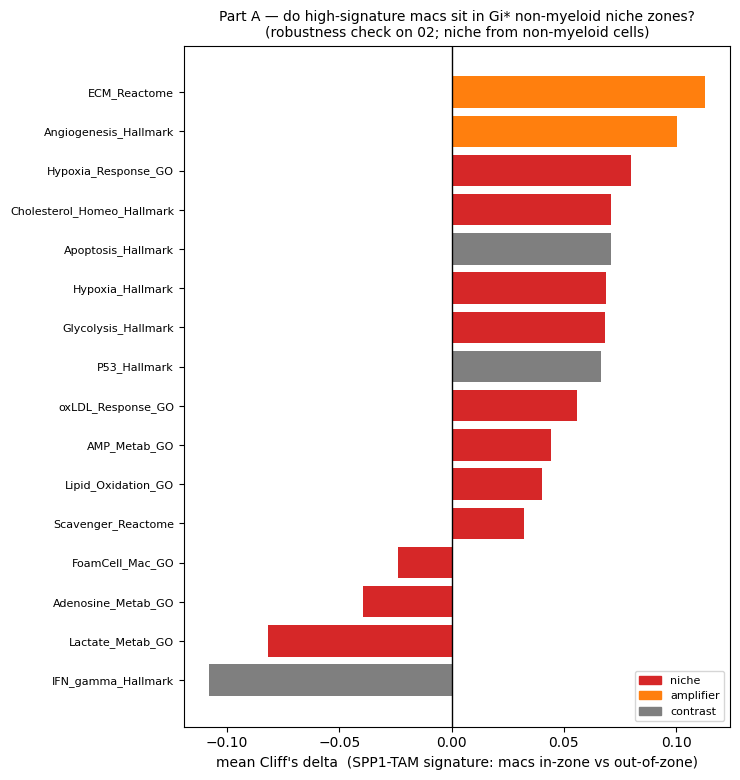

In [8]:
plot = robust_summary.sort_values("mean_delta")
tier_c = {"niche": "#d62728", "amplifier": "#ff7f0e", "contrast": "#7f7f7f"}
fig, ax = plt.subplots(figsize=(7.5, 0.4 * len(plot) + 1.5))
ax.barh(range(len(plot)), plot["mean_delta"].values, color=[tier_c[t] for t in plot["tier"]])
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot["pathway"], fontsize=8)
ax.set_xlabel("mean Cliff's delta  (SPP1-TAM signature: macs in-zone vs out-of-zone)")
ax.set_title("Part A — do high-signature macs sit in Gi* non-myeloid niche zones?\n"
             "(robustness check on 02; niche from non-myeloid cells)", fontsize=10)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=t) for t, c in tier_c.items()], fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_niche_gistar_robustness.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 5. Part B — what cell types surround high-signature macrophages?

Within each tissue, split macs at the `SPP1_TAM_sig` tertiles: **high** = top third,
**low** = bottom third (middle dropped). For every mac, the composition of its neighborhood
within `NEIGHBOR_RADIUS_UM` (excluding itself). Then: does cell type X take a larger share of
the neighborhood of **high**-signature than **low**-signature macs, in the same tissue?

In [9]:
CT_OF_INTEREST = ["Cancer_cell", "Fibroblast", "Endothelial", "CD8_T", "CD4_T", "Treg", "NK", "NKT",
                  "B", "cDC", "pDC", "Classical_Mono", "Nonclassical_Mono",
                  "N1_like_Neu", "N2_like_Neu", "M1_like_Mac", "M2_like_Mac", "Erythrocyte"]

rows = []
for ti, tname in enumerate(tissues, 1):
    mask, coords_um = coords_um_for(adata, sdata, tname)
    if mask.sum() < MIN_CELLS:
        continue
    obs_t = adata.obs.loc[mask]
    mac_u = obs_t["is_mac"].values.astype(bool)
    if mac_u.sum() < MIN_MACS_PER_TISSUE:
        print(f"skip {tname}: {int(mac_u.sum())} macs"); continue
    sig = obs_t["SPP1_TAM_sig"].to_numpy(float)
    sig_mac = sig[mac_u]
    qlo, qhi = np.quantile(sig_mac, SIG_SPLIT_Q), np.quantile(sig_mac, 1 - SIG_SPLIT_Q)
    high_u = mac_u & (sig >= qhi)
    low_u  = mac_u & (sig < qlo)          # strict: no overlap with high when qlo == qhi (ties)
    if high_u.sum() < MIN_GROUP or low_u.sum() < MIN_GROUP:
        print(f"skip {tname}: high={int(high_u.sum())} low={int(low_u.sum())}"); continue
    cond, loc, rep = parse_tissue(tname)
    ct_t = obs_t[CELL_TYPE_COL].astype(str).values
    cts = [c for c in CT_OF_INTEREST if (ct_t == c).sum() > 0]
    print(f"[{ti}/{len(tissues)}] {tname} neighborhoods: high={int(high_u.sum()):,} "
          f"low={int(low_u.sum()):,}", flush=True)

    nn = NearestNeighbors(radius=NEIGHBOR_RADIUS_UM).fit(coords_um)

    def composition(anchor_mask):
        nbrs = nn.radius_neighbors(coords_um[anchor_mask], return_distance=False)
        anchor_idx = np.where(anchor_mask)[0]
        counts = {c: [] for c in cts}
        for self_i, nb in zip(anchor_idx, nbrs):
            nb = nb[nb != self_i]                      # drop the anchor itself
            if len(nb) == 0:
                continue
            lab, cnt = np.unique(ct_t[nb], return_counts=True)
            frac = dict(zip(lab, cnt / len(nb)))
            for c in cts:
                counts[c].append(frac.get(c, 0.0))
        return {c: (np.mean(v) if v else np.nan) for c, v in counts.items()}

    comp_hi, comp_lo = composition(high_u), composition(low_u)
    for c in cts:
        p, q = comp_hi[c], comp_lo[c]
        rows.append({"tissue": tname, "cond": cond, "tumor_loc": loc, "rt_group": rt_group_of(cond, loc),
                     "celltype": c, "frac_around_high": p, "frac_around_low": q, "diff": p - q,
                     "log2_ratio": float(np.log2(p / q)) if (p > 0 and q > 0) else np.nan})

neigh = pd.DataFrame(rows)
neigh.to_csv(OUT_DIR / "spp1tam_celltype_neighborhood_long.csv", index=False)

rows = []
for c, sub in neigh.groupby("celltype", observed=True):
    paired = sub.dropna(subset=["frac_around_high", "frac_around_low"])
    if len(paired) < 3:
        continue
    try:
        p = wilcoxon(paired["frac_around_high"], paired["frac_around_low"]).pvalue
    except Exception:
        p = np.nan
    rows.append({"celltype": c, "n_tissues": len(paired),
                 "mean_around_high": paired["frac_around_high"].mean(),
                 "mean_around_low": paired["frac_around_low"].mean(),
                 "mean_log2_ratio": sub["log2_ratio"].mean(),
                 "frac_tissues_up": float((sub["diff"] > 0).mean()), "wilcoxon_p": p})
neigh_summary = pd.DataFrame(rows)
ok = neigh_summary["wilcoxon_p"].notna()
neigh_summary.loc[ok, "q"] = multipletests(neigh_summary.loc[ok, "wilcoxon_p"], method="fdr_bh")[1]
neigh_summary = neigh_summary.sort_values("mean_log2_ratio", ascending=False)
neigh_summary.to_csv(OUT_DIR / "spp1tam_celltype_neighborhood_summary.csv", index=False)

print(f"\n=== PART B: cell types around HIGH- vs LOW-signature macrophages ({NEIGHBOR_RADIUS_UM} um) ===")
print(neigh_summary.round(4).to_string(index=False))
print("\npositive log2_ratio = over-represented around high-signature macs (vs low, same tissue)")

[1/32] CyPSCA_1_1 neighborhoods: high=638 low=638
[2/32] CyPSCA_1_2 neighborhoods: high=383 low=383
[3/32] CyPSCA_1_3 neighborhoods: high=1,247 low=1,247
[4/32] CyPSCA_1_4 neighborhoods: high=446 low=446
[5/32] CyPSCA_2_1 neighborhoods: high=1,378 low=1,378
[6/32] CyPSCA_2_2 neighborhoods: high=721 low=721
[7/32] CyPSCA_2_3 neighborhoods: high=1,010 low=1,010
[8/32] CyPSCA_2_4 neighborhoods: high=945 low=945
[9/32] CyT72_1_2 neighborhoods: high=1,368 low=1,367
[10/32] CyT72_1_4 neighborhoods: high=1,491 low=1,490
[11/32] CyT72_2_3 neighborhoods: high=2,056 low=2,056
skip CyT72_2_4: 12 macs
[13/32] NoTx_1_1 neighborhoods: high=195 low=195
skip NoTx_1_2: 4 macs
skip NoTx_1_3: 11 macs
skip NoTx_1_4: 20 macs
skip NoTx_2_1: 3 macs
skip NoTx_2_2: 44 macs
[19/32] NoTx_2_3 neighborhoods: high=19 low=19
skip NoTx_2_4: 7 macs
[21/32] RTCyPSCA_1_2 neighborhoods: high=209 low=208
[22/32] RTCyPSCA_1_3 neighborhoods: high=931 low=930
[23/32] RTCyPSCA_1_4 neighborhoods: high=1,004 low=1,004
[24/32] R

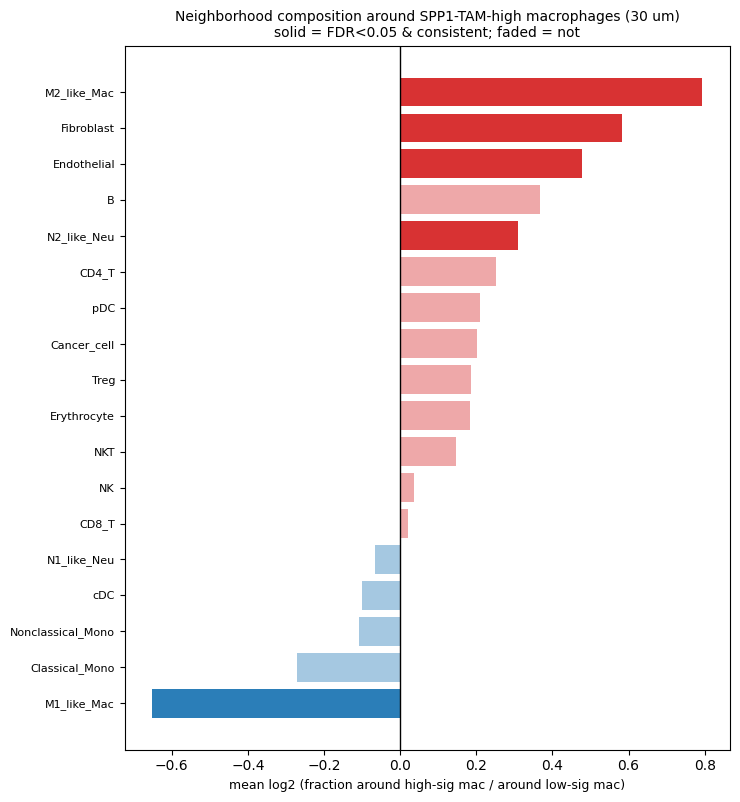

In [10]:
plot_df = neigh_summary.dropna(subset=["mean_log2_ratio"]).sort_values("mean_log2_ratio")
y = np.arange(len(plot_df))
sig_ok = (plot_df["q"] < 0.05) & (plot_df["frac_tissues_up"].sub(0.5).abs() > 0.2)
bar_cols = [mcolors.to_rgba("#d62728" if v > 0 else "#1f77b4", 0.95 if s else 0.4)
            for v, s in zip(plot_df["mean_log2_ratio"].values, sig_ok.values)]
fig, ax = plt.subplots(figsize=(7.5, 0.34 * len(plot_df) + 2))
ax.barh(y, plot_df["mean_log2_ratio"], color=bar_cols)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(y); ax.set_yticklabels(plot_df["celltype"], fontsize=8)
ax.set_xlabel("mean log2 (fraction around high-sig mac / around low-sig mac)", fontsize=9)
ax.set_title(f"Neighborhood composition around SPP1-TAM-high macrophages ({NEIGHBOR_RADIUS_UM} um)\n"
             "solid = FDR<0.05 & consistent; faded = not", fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_celltype_neighborhood.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 6. Does the neighborhood change with RT?

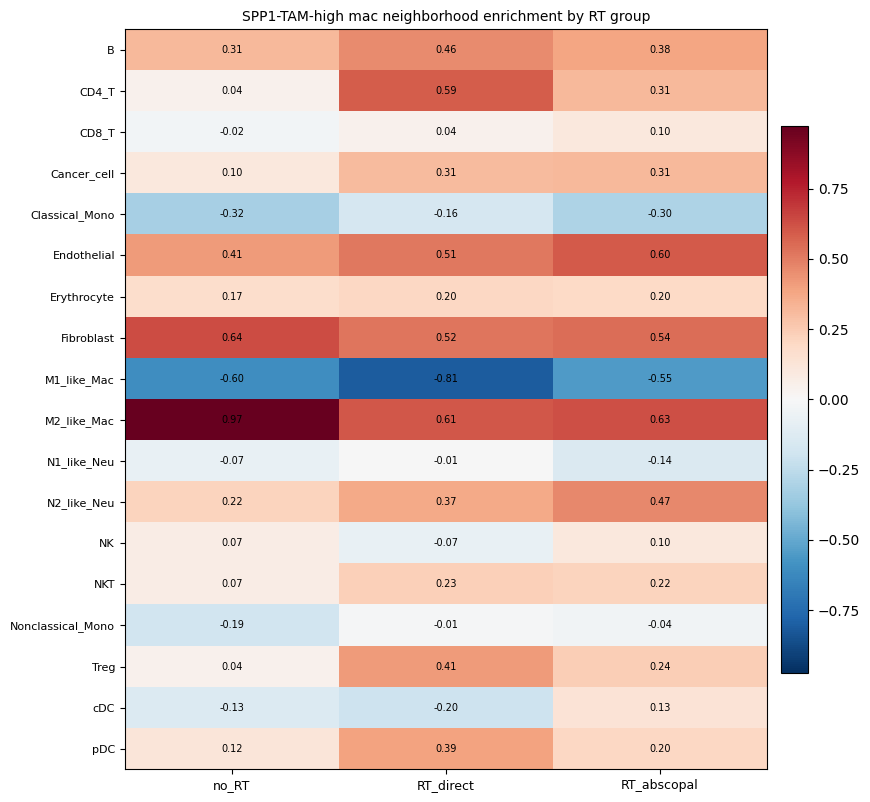

In [11]:
piv = (neigh.groupby(["celltype", "rt_group"], observed=True)["log2_ratio"]
       .mean().unstack("rt_group"))
piv = piv.reindex(columns=[c for c in ["no_RT", "RT_direct", "RT_abscopal"] if c in piv.columns])
piv.to_csv(OUT_DIR / "spp1tam_neighborhood_by_rt_group.csv")

data = piv.values.astype(float)
vmax = np.nanmax(np.abs(data)) or 1.0
fig, ax = plt.subplots(figsize=(1.6 * data.shape[1] + 4, 0.34 * data.shape[0] + 2))
im = ax.imshow(data, cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax), aspect="auto")
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(piv.columns, fontsize=9)
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(piv.index, fontsize=8)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if np.isfinite(data[i, j]):
            ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("SPP1-TAM-high mac neighborhood enrichment by RT group", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1tam_neighborhood_by_rt.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 7. Summary

In [12]:
print(f"""
==================== SUMMARY — report these back ====================
PART A (Gi* hotspot robustness; niche = non-myeloid cells only)
  tissues: {niche_robust['tissue'].nunique()} | pathways: {niche_robust['pathway'].nunique()}
  Niches where high-signature macs sit IN the zone (top mean delta):
{robust_summary.nlargest(5, 'mean_delta')[['pathway','tier','mean_delta','frac_pos','q']].round(3).to_string(index=False)}

  ACTION: put mean_delta next to 02's mean_rho (auto-printed above). Where both are positive on
  the niche tier, the SPP1-TAM-in-niche finding is robust to how the niche is defined. Where the
  Gi* delta collapses toward 0, 02's local-mean correlation was operationalization-specific.

PART B (neighborhood composition, high- vs low-signature macs, {NEIGHBOR_RADIUS_UM} um)
  tissues: {neigh['tissue'].nunique()}
  Most OVER-represented around high-signature macs:
{neigh_summary.nlargest(5, 'mean_log2_ratio')[['celltype','mean_log2_ratio','q','frac_tissues_up']].round(3).to_string(index=False)}
  Most DEPLETED around high-signature macs:
{neigh_summary.nsmallest(5, 'mean_log2_ratio')[['celltype','mean_log2_ratio','q','frac_tissues_up']].round(3).to_string(index=False)}

  The PDF predicts: Fibroblast UP (FAP+ immune-excluding niche), Cancer_cell UP (debris source),
  CD8_T DOWN (immune exclusion). A CD8 depletion around high-signature macs is the single most
  quotable result here — it turns a descriptive state into a functional, treatment-relevant claim.
  'Erythrocyte' is the flagged junk compartment; treat its bar as QC, not biology.

  Caveat: segmentation spillover inflates apparent co-location for ANY adjacent pair. The
  low-signature mac reference controls for it as long as both groups are segmented the same way.
=====================================================================
""")


==================== SUMMARY — report these back ====================
PART A (Gi* hotspot robustness; niche = non-myeloid cells only)
  tissues: 25 | pathways: 16
  Niches where high-signature macs sit IN the zone (top mean delta):
                   pathway      tier  mean_delta  frac_pos     q
              ECM_Reactome amplifier       0.113     0.833 0.001
     Angiogenesis_Hallmark amplifier       0.101     0.792 0.001
       Hypoxia_Response_GO     niche       0.080     0.750 0.014
Cholesterol_Homeo_Hallmark     niche       0.071     0.792 0.007
        Apoptosis_Hallmark  contrast       0.071     0.667 0.008

  ACTION: put mean_delta next to 02's mean_rho (auto-printed above). Where both are positive on
  the niche tier, the SPP1-TAM-in-niche finding is robust to how the niche is defined. Where the
  Gi* delta collapses toward 0, 02's local-mean correlation was operationalization-specific.

PART B (neighborhood composition, high- vs low-signature macs, 30 um)
  tissues: 25
  Mos